# Classifications Analyzer
This notebook can be used to study the classified set, or subsets based on any assortment of values.
It has been used to identify limitations in classifying SGA 2020 large galaxies, and to confirm known relationships in the SGA 2025 classifications

In [1]:
import numpy as np
from astropy.table import Table, vstack, join
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
sga2020 = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', hdu=1)
sga2020.sort('D26')
sga2020.reverse()
unc = Table.read("/pscratch/sd/q/qshimp/SGA2020-data/unclassified-sga-ids.csv")
filter = np.isin(sga2020['SGA_ID'], unc['SGA_ID'])
unc2020 = sga2020[filter]
sga2020

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
972325,SGA-2020 972325,NGC0598,5818,23.462120999999996,30.659925199999996,Sc,22.67,62.086903,0.5915616,-0.00060808734,23.94448,6.351,False,LEDA-20181114,345318,NGC0598_GROUP,3,True,23.461713020137164,30.662208518892047,62.22551,0233p307,23.466574222031817,30.657238223410136,77.60863,LEDA,22.67,0.5915616,23.462120999999996,30.659925199999996,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,16
2000074,SGA-2020 2000074,NGC0055,1014,3.7233333333333327,-39.19666666666665,Irr,102.0,29.85382,0.10209395,0.00043143812,23.90348,7.9,False,LGDWARFS,248999,NGC0055_GROUP,5,True,3.7236154734643803,-39.19453073574043,29.982647,0037m392,3.7208168866380826,-39.19760821466396,37.317276,LEDA,102.0,0.10209395,3.7233333333333327,-39.19666666666665,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-

In [3]:
# Unclassified galaxies
set = Table()
set['SGA_ID'] = unc2020['SGA_ID']
set['RA'] = unc2020['RA']
set['DEC'] = unc2020['DEC']
set['D26'] = unc2020['D26']
set

SGA_ID,RA,DEC,D26
int64,float64,float64,float32
202991,154.52406681557585,21.83273356523772,9.152969
936305,186.61254167553952,31.22327040125801,7.9418693
671847,183.2171475353631,1.299694382515313,7.845586
744519,189.11246074261086,11.439215737152313,6.557759
232251,309.3012529372103,-54.66134350154012,5.7518506
1325182,158.185442577391,-28.60982511253221,4.801255
1213101,54.23765137837437,-35.50656125229363,4.70708
444224,96.90116041782468,-54.44942976812785,4.3248725
763501,184.9386609765295,12.79825026424119,4.305506


In [4]:
# Full 2020 set
set20 = Table()
set20['SGA_ID'] = sga2020['SGA_ID']
set20['RA'] = sga2020['RA']
set20['DEC'] = sga2020['DEC']
set20['D26'] = sga2020['D26']
set20

SGA_ID,RA,DEC,D26
int64,float64,float64,float32
972325,23.466574222031817,30.657238223410136,77.60863
2000074,3.7208168866380826,-39.19760821466396,37.317276
1121881,11.888538371043955,-25.291632246193373,33.4896
1237406,210.8030425957459,54.34885971354772,29.98542
717287,11.78368893292357,-20.758055785028606,27.569998
1314798,148.8894704108722,69.06514213964773,27.033981
2000076,13.72362439938066,-37.68409464109935,25.0
336131,184.1794767280482,69.46198730282079,23.862352
2000055,16.19834038265351,2.1206286084517556,22.90393


In [5]:
PIX_SCALE       = 0.262       # arcsec/pixel for Legacy Surveys
CUTOUT_SIZE_PIX = 152         # fixed 152x152 cutouts
diamMax = PIX_SCALE*CUTOUT_SIZE_PIX/60 # max diameter in arcmin
print(f"Cutout length/height: {diamMax * 60} arcsec")

def binImage(table, diam):
    global num
    global i
    num = 0
    i = 0
     # Create separate tables for each bin 
    imgBins = []
    while num < len(table):
        imgBins.append(table[(table[diam] > i*diamMax) & (table[diam] <= (i+1)*diamMax)])
        num += len(imgBins[i])
        print(f"{len(imgBins[i])} targets in sample {i}")
        i+=1
    return imgBins, i


Cutout length/height: 39.824 arcsec


In [6]:
setBins, idx = binImage(set, 'D26')

2616 targets in sample 0
2201 targets in sample 1
304 targets in sample 2
76 targets in sample 3
19 targets in sample 4
2 targets in sample 5
3 targets in sample 6
2 targets in sample 7
1 targets in sample 8
1 targets in sample 9
0 targets in sample 10
2 targets in sample 11
0 targets in sample 12
1 targets in sample 13


In [7]:
sgaBins, jdx = binImage(sga2020, 'D26')

211138 targets in sample 0
145699 targets in sample 1
18275 targets in sample 2
4807 targets in sample 3
1731 targets in sample 4
745 targets in sample 5
402 targets in sample 6
229 targets in sample 7
157 targets in sample 8
107 targets in sample 9
63 targets in sample 10
61 targets in sample 11
46 targets in sample 12
42 targets in sample 13
19 targets in sample 14
13 targets in sample 15
12 targets in sample 16
10 targets in sample 17
14 targets in sample 18
8 targets in sample 19
11 targets in sample 20
2 targets in sample 21
5 targets in sample 22
1 targets in sample 23
2 targets in sample 24
2 targets in sample 25
0 targets in sample 26
1 targets in sample 27
1 targets in sample 28
1 targets in sample 29
0 targets in sample 30
5 targets in sample 31
0 targets in sample 32
2 targets in sample 33
1 targets in sample 34
1 targets in sample 35
0 targets in sample 36
1 targets in sample 37
0 targets in sample 38
0 targets in sample 39
1 targets in sample 40
1 targets in sample 41
0 ta

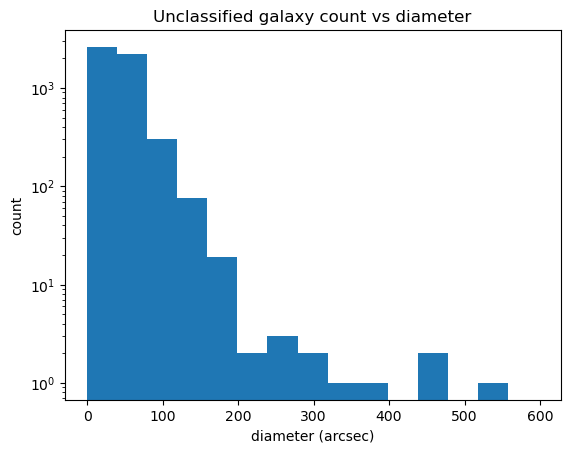

In [8]:
plt.figure()
plt.hist(60*set["D26"], bins=np.arange(0,diamMax*60*(idx+1),diamMax*60))
plt.yscale('log')
plt.xlabel("diameter (arcsec)")
plt.ylabel("count")
plt.title("Unclassified galaxy count vs diameter") 
plt.show()

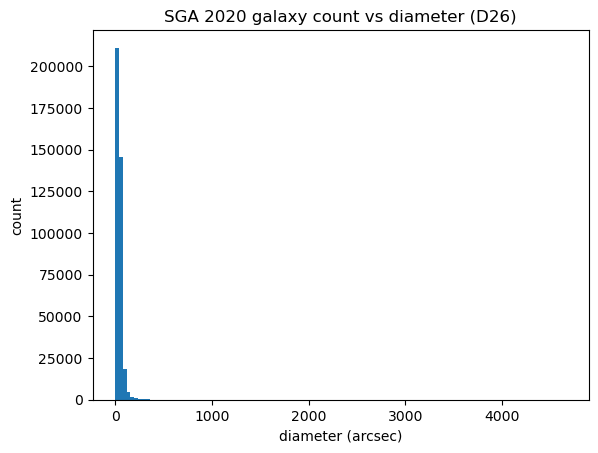

In [29]:
plt.figure()
plt.hist(60*sga2020["D26"], bins=np.arange(0,diamMax*60*(jdx+1),diamMax*60))
plt.xlabel("diameter (arcsec)")
plt.ylabel("count")
plt.title("SGA 2020 galaxy count vs diameter (D26)") 
plt.show()

In [10]:
# Completing the final classifications SGA 2020 table . . . 
final = Table.read("/global/cfs/cdirs/desi/science/td/pv/SGA2020/final_classifications_SGA2020.csv")
anchors = Table.read("/pscratch/sd/q/qshimp/SGA2020-data/Anchors/VI_4000_sga152x152_complete.csv")

# Fix anchor morphology names
anchors['Morphology'] = anchors['Morphology'].astype('<U24')
anchors['Morphology'][anchors['Main_type'] == 20] = 'Elliptical'
anchors['Morphology'][anchors['Main_type'] == 10] = 'Spiral'
anchors['Morphology'][anchors['Main_type'] == 0] = 'Lenticular'
anchors['Morphology'][anchors['Main_type'] == -5] = 'Irregular'

# Prepare anchors for stacking
anchors_prepped = Table()
anchors_prepped['SGA_ID'] = anchors['ref_id']
anchors_prepped['Classification'] = anchors['Morphology']

# Isolate missing galaxies

mask = ~np.isin(sga2020['SGA_ID'], final['SGA_ID'])
filtered_table = sga2020[mask]
mask = ~np.isin(filtered_table['SGA_ID'], anchors['ref_id'])
missing = filtered_table[mask]
missing['MORPHTYPE'] = 'Unclassified'

# Links to missing galaxies: 
# https://www.legacysurvey.org/viewer?ra=304.2976&dec=-62.2112&layer=ls-dr10&zoom=15
# https://www.legacysurvey.org/viewer?ra=304.3310&dec=-62.3555&layer=ls-dr10&zoom=15

# Prepare missing galaxies for stacking
missing_prepped = Table()
missing_prepped['SGA_ID'] = missing['SGA_ID']
missing_prepped['Classification'] = missing['MORPHTYPE'].astype('<U24')

# Stack and sort all SGA 2020 galaxies
complete = vstack([final, anchors_prepped, missing_prepped])
complete['SGA_ID'] = complete['SGA_ID'].astype(np.int64)
complete.sort(['SGA_ID'])

# Sanity check
print(np.unique(complete['Classification']))

Classification
--------------
    Elliptical
     Irregular
    Lenticular
        Spiral
  Unclassified


In [11]:
# Split complete set into classes
classes = complete.group_by('Classification').groups

# How are the largest galaxies classified?
large = sga2020['SGA_ID'][:31]
for id in large:
    for i in range(0,5,1):
        find = classes[i][classes[i]['SGA_ID'] == id]
        if not len(find) == 0:
            print(f'{int(find['SGA_ID'][0])} is {(find['Classification'][0]).lower()}')

972325 is irregular
2000074 is irregular
1121881 is irregular
1237406 is lenticular
717287 is irregular
1314798 is irregular
2000076 is irregular
336131 is irregular
2000055 is irregular
977015 is irregular
866686 is irregular
669240 is irregular
1409117 is irregular
52700 is lenticular
178440 is irregular
526710 is irregular
608539 is lenticular
775303 is irregular
1217554 is irregular
696291 is irregular
2000022 is irregular
372770 is lenticular
488160 is lenticular
1345315 is lenticular
712432 is irregular
937823 is lenticular
126782 is irregular
685925 is lenticular
1001279 is lenticular
1410811 is irregular
313506 is irregular


In [12]:
diamVals = join(complete, set20, keys='SGA_ID', join_type='inner')
diamVals

SGA_ID,Classification,RA,DEC,D26
int64,str24,float64,float64,float32
2,Spiral,228.3770803831908,5.423191398593787,0.49470574
3,Spiral,202.5444619671207,6.9346244322326624,0.55350494
4,Irregular,222.7497050504303,13.861929561160224,0.37067476
7,Spiral,182.08882232629614,25.60226821438983,0.8883204
18,Elliptical,188.53364923054596,45.595620212931856,0.73435897
20,Irregular,263.55294849855886,57.344862145664294,0.4460123
24,Elliptical,247.42445048371366,40.24820033835744,0.5431378
25,Irregular,227.47031353123606,13.256402782093659,0.9032927
26,Elliptical,163.5984039051307,54.41298240323229,0.3833318


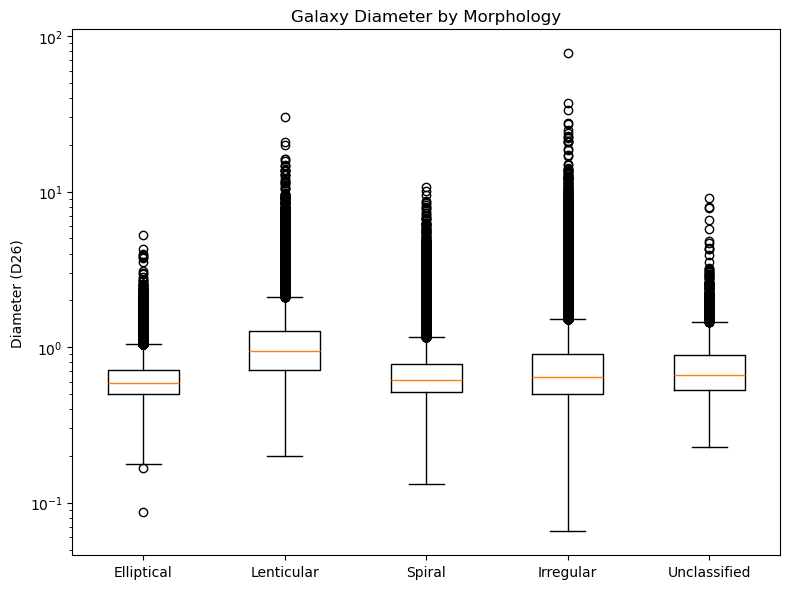

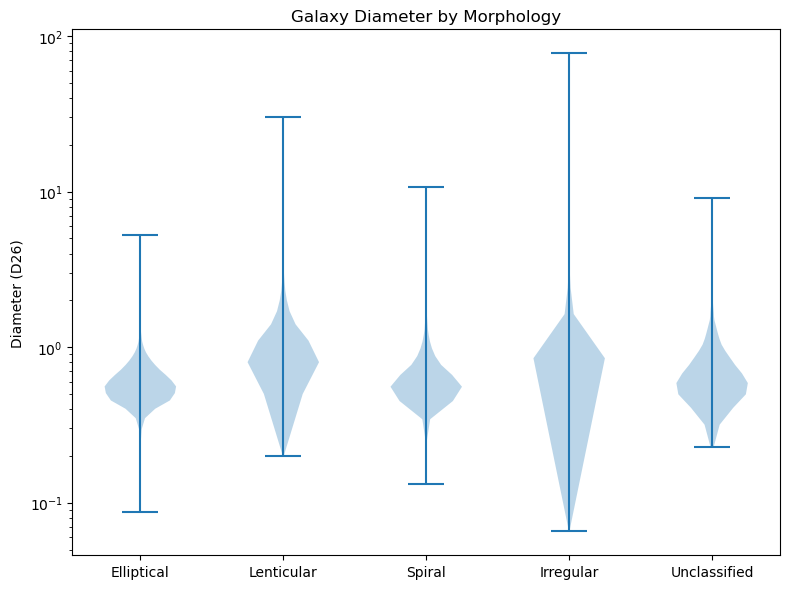

Elliptical: 94518 galaxies
Lenticular: 46161 galaxies
Spiral: 163967 galaxies
Irregular: 73744 galaxies
Unclassified: 5230 galaxies


In [13]:
classes = ['Elliptical', 'Lenticular', 'Spiral', 'Irregular', 'Unclassified']

data = [diamVals['D26'][diamVals['Classification'] == c] for c in classes]

# Boxplot
plt.figure(figsize=(8,6))
plt.boxplot(data, tick_labels=classes)
plt.yscale('log')
plt.ylabel("Diameter (D26)")
plt.title("Galaxy Diameter by Morphology")
plt.tight_layout()
plt.show()

# Violin plot
plt.figure(figsize=(8,6))
plt.violinplot(data)
plt.xticks(range(1, len(classes)+1), classes)
plt.yscale('log')
plt.ylabel("Diameter (D26)")
plt.title("Galaxy Diameter by Morphology")
plt.tight_layout()
plt.show()

for c, d in zip(classes, data):
    print(f"{c}: {len(d)} galaxies")

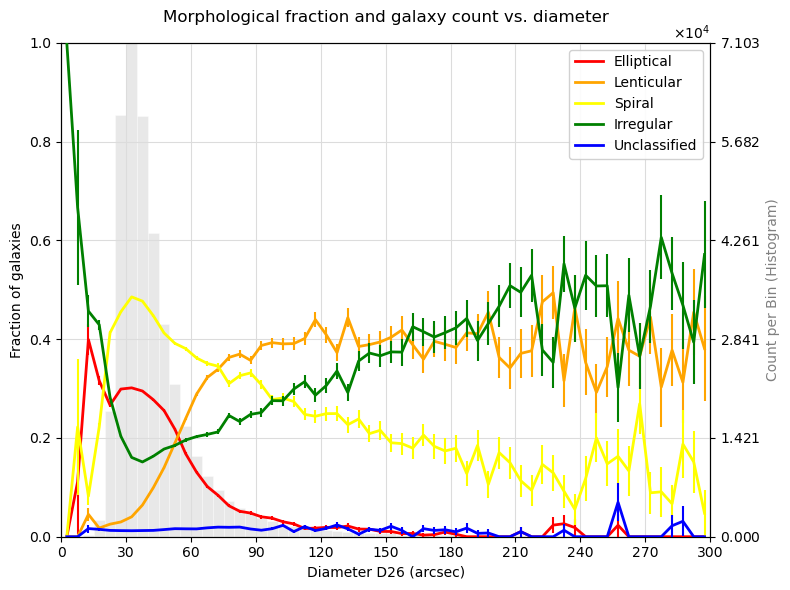

In [24]:
# Diameter values
diam = np.asarray(diamVals['D26']*60)
hist_data = 60 * sga2020["D26"]

a = 0
b = 300
# Define unified bins for BOTH the fractions and the histogram
n_bins = 60
edges = np.linspace(a, b, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

# 1. Initialize a single figure and the primary axes (for fractions)
fig, ax1 = plt.subplots(figsize=(8, 6))

# 2. Create a secondary Y-axis for the histogram that shares the same X-axis
ax2 = ax1.twinx()

# --- BACKGROUND: Galaxy Count Histogram ---
# Crucial Fix: We now pass the exact same 'edges' array to the histogram
counts, bin_edges = np.histogram(hist_data, bins=edges)
ax2.hist(hist_data, bins=edges, color='lightgray', alpha=0.5, edgecolor='white', linewidth=0.5, zorder=1)
ax2.set_ylabel("Count per Bin (Histogram)", color='gray')

# --- FOREGROUND: Morphological Fractions ---
colors = ['red', 'orange', 'yellow', 'green', 'blue']

for color_idx, c in enumerate(classes):
    fractions = []
    errors = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (diam >= lo) & (diam < hi)
        total = np.sum(in_bin)

        if total == 0:
            fractions.append(np.nan)
            errors.append(np.nan)
        else:
            frac = np.sum(in_bin & (diamVals['Classification'] == c)) / total
            error = np.sqrt(frac * (1 - frac) / total)
            fractions.append(frac)
            errors.append(error)
            
    # Plot on the primary axes (ax1)
    ax1.plot(centers, fractions, label=c, color=colors[color_idx], linewidth=2, zorder=3)
    ax1.errorbar(centers, fractions, yerr=errors, fmt='none', ecolor=colors[color_idx], zorder=3)

ax1.set_xlabel("Diameter D26 (arcsec)")
ax1.set_ylabel("Fraction of galaxies")
ax1.set_title("Morphological fraction and galaxy count vs. diameter", pad=15)

# --- PERFECT Y-AXIS GRIDLINE ALIGNMENT ---
ax1.set_ylim(0, 1.0)
ax1.set_yticks(np.linspace(0, 1.0, 6))

# Automatically scale the Histogram axis to match those 6 ticks cleanly
max_count = np.max(counts)
ax2_max = int(np.ceil(max_count / 5.0) * 5)
ax2.set_ylim(0, ax2_max)
ax2.set_yticks(np.linspace(0, ax2_max, 6))

# Handle gridlines 
ax1.grid(True, which='major', color='gainsboro', linestyle='-', zorder=0)
ax2.grid(False) 

# Fix scientific notation overlapping 
ax2.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0, 3))

# Layering layout fixes
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# --- GLOBAL SETTINGS ---
ax1.set_xlim(a, b)
ax1.set_xticks(np.arange(a, b + 1, (b - a) / 10))
ax1.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()
